In [ ]:
!wget https://raw.githubusercontent.com/ye-kyaw-thu/sylbreak/master/python/sylbreak.py

--2025-12-24 07:23:18--  https://raw.githubusercontent.com/ye-kyaw-thu/sylbreak/master/python/sylbreak.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3668 (3.6K) [text/plain]
Saving to: ‘sylbreak.py’

sylbreak.py         100%[===================>]   3.58K  --.-KB/s    in 0s      

2025-12-24 07:23:18 (98.7 MB/s) - ‘sylbreak.py’ saved [3668/3668]



In [ ]:
!pip install transformers==4.41.1 peft==0.11.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 91.4 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.1
    Uninstalling tokenizers-0.22.1:
      Successfully uninstalled tokenizers-0.22.1
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.3
    Uninstalling transformers-4.57.3:
      Successfully uninstalled transformers-4.57.3
  Attempting uninstall: peft
    Found existing installation: peft 0.18.0
    Uninstalling peft-0.18.0:
      Successfully uninstalled peft-0.18.0


In [ ]:
!pip install 'datasets[audio]==2.14.4' 'fsspec==2023.9.2'

INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.3/519.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.4/173.4 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 4.9 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: dill
    Found existing installation: dill 0.3.8
    Uninstalling dill-0.3.8:
      Successfully uninstalled dill-0.3.8
  Attempting uninstall: multiprocess
    Found existing installation: multiprocess 0.70.16
    Uninstalling multiprocess-0.70.16:
      Successfully uninstalled multiprocess-0.70.16
  Attempting uninstall: datasets
    Found e

In [ ]:
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 38.5 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset
speech_data = load_dataset("LULab/mediTalk-mm-rdy", split='test')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Extracting data files:   0%|          | 0/2 [00:00<?, ?it/s]

Generating test split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
from sylbreak import break_syllables, create_break_pattern

def syllable_break(text):
  """Syllable break for burmese texts"""
  text = text
  separator = ' '
  break_pattern = create_break_pattern()

  segmented = break_syllables(text, break_pattern, separator)
  return segmented

In [ ]:
def apply_syllable_break(text):
    text['prompt'] = syllable_break(text['prompt'])
    return text

dataset = speech_data.map(apply_syllable_break)
dataset

Map:   0%|          | 0/2920 [00:00<?, ? examples/s]

Dataset({
    features: ['speaker_id', 'prompt', 'audio'],
    num_rows: 2920
})

In [ ]:
speech_data = dataset.select(range(30))
speech_data

Dataset({
    features: ['speaker_id', 'prompt', 'audio'],
    num_rows: 30
})

In [ ]:
from transformers import pipeline
import torch

MODEL_NAME = "YeBhoneLin10/Whisper-Medium-Org-FFT"  # specify the model name
lang = "my"  # change to Thai langauge

device = 0 if torch.cuda.is_available() else "cpu"

pipe = pipeline(
    task="automatic-speech-recognition",
    model=MODEL_NAME,
    chunk_length_s=10,
    stride_length_s=2,
    device=device,
)
pipe.model.config.forced_decoder_ids = pipe.tokenizer.get_decoder_prompt_ids(
  language=lang,
  task="transcribe"
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.06G [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


preprocessor_config.json:   0%|          | 0.00/339 [00:00<?, ?B/s]

In [ ]:
import numpy as np

def add_noise_snr(clean_audio, snr_db):
    """
    Add Gaussian noise to achieve target SNR (dB)
    """
    clean_audio = np.asarray(clean_audio, dtype=np.float32)

    signal_power = np.mean(clean_audio ** 2)
    snr_linear = 10 ** (snr_db / 10)
    noise_power = signal_power / snr_linear

    noise = np.random.normal(0, np.sqrt(noise_power), clean_audio.shape)
    noisy_audio = clean_audio + noise

    return noisy_audio


In [ ]:
from tqdm import tqdm
import pandas as pd
import librosa
import json
from jiwer import wer

OUTPUT_JSON = "whisper_snr_wer_results.json"
snr_levels = [-20, -15, -10, -5, 0, 5, 10, 15, 20]
results = []

for snr in snr_levels:
    print(f"\nEvaluating SNR = {snr} dB")

    for idx, item in enumerate(tqdm(speech_data)):
        audio = item["audio"]

        if isinstance(audio, dict):
            clean_audio = audio["array"]
            sr = audio["sampling_rate"]
        else:
            clean_audio = audio
            sr = 16000

        if sr != 16000:
            clean_audio = librosa.resample(clean_audio, orig_sr=sr, target_sr=16000)

        noisy_audio = add_noise_snr(clean_audio, snr)

        result = pipe({
            "array": noisy_audio,
            "sampling_rate": 16000
        })

        hypothesis = result["text"].strip()
        reference = item["prompt"].strip()

        error = wer(reference, hypothesis)

        wer_percent = error * 100
        wer_format = f"{wer_percent:.2f}"

        results.append({
            "utt_id": idx,
            "snr_db": snr,
            "reference": reference,
            "hypothesis": hypothesis,
            "wer": wer_format
        })



Evaluating SNR = -20 dB


100%|██████████| 5/5 [00:36<00:00,  7.33s/it]



Evaluating SNR = -15 dB


100%|██████████| 5/5 [00:31<00:00,  6.33s/it]



Evaluating SNR = -10 dB


...

100%|██████████| 5/5 [00:27<00:00,  5.46s/it]



Evaluating SNR = 15 dB


100%|██████████| 5/5 [00:26<00:00,  5.32s/it]



Evaluating SNR = 20 dB


100%|██████████| 5/5 [00:27<00:00,  5.43s/it]


In [ ]:
with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

In [ ]:
#import json
#import pandas as pd

#with open("/content/whisper_snr_wer_results.json", "r", encoding="utf-8") as f:
#    data = json.load(f)

#df1 = pd.DataFrame(data)

In [ ]:
# print(df1["wer"].dtype)
# print(df1["wer"].head(10))

object
0    122.03
1    166.67
2    109.52
3    169.23
4    209.09
5    100.00
6    126.67
7    104.76
8     92.31
9    200.00
Name: wer, dtype: object


In [ ]:
# df1["wer"] = df1["wer"].astype(float)

In [ ]:
# snr_summary1 = (
#    df1
#    .groupby("snr_db")
#    .agg(
#        avg_wer=("wer", "mean"),
#        std_wer=("wer", "std"),
#        num_utts=("wer", "count")
#    )
#    .reset_index()
#    .sort_values("snr_db")
# )

# print(snr_summary1)


   snr_db  avg_wer    std_wer  num_utts
0     -20  155.308  40.060538         5
1     -15  124.748  43.962385         5
2     -10   85.714  20.590010         5
3      -5   57.388  25.633406         5
4       0   33.240  20.483319         5
5       5   27.298  25.440678         5
6      10   17.608  13.625704         5
7      15   14.780  10.788478         5
8      20   12.876   9.567368         5


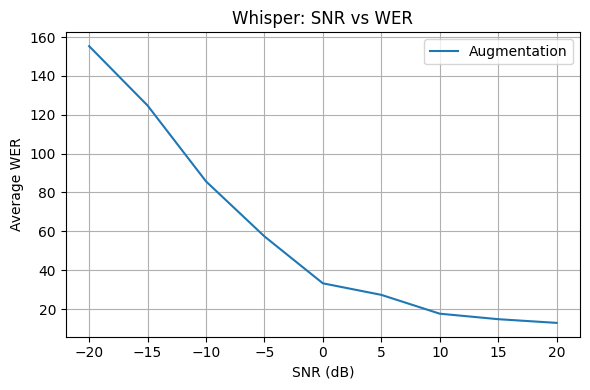

In [ ]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(6, 4))

# plt.errorbar(
#    snr_summary1["snr_db"],
#    snr_summary1["avg_wer"],
#    capsize=4,
#    label="Augmentation"
#)

#plt.xlabel("SNR (dB)")
#plt.ylabel("Average WER")
#plt.title("Whisper: SNR vs WER")
#plt.grid(True)
#plt.legend()
#plt.tight_layout()
#plt.show()
